In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.pandas.set_option("display.max_columns", None)

In [28]:
data = pd.read_csv("customer_churn.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [29]:
data.shape

(7043, 21)

In [30]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [31]:
data = data.drop("customerID", axis = 1)
data.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [32]:
data.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [33]:
data.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [34]:
data[data["TotalCharges"]==' '].shape

(11, 20)

In [35]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors='coerce')

In [36]:
data.isna().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [37]:
data.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [38]:
data[data["TotalCharges"].isna() == 1]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [39]:
data["TotalCharges"] = data.apply(lambda df: df["tenure"] * df["MonthlyCharges"] if pd.isna(df["TotalCharges"]) else df["TotalCharges"], axis=1)
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [40]:
data.loc[488]

gender                                 Female
SeniorCitizen                               0
Partner                                   Yes
Dependents                                Yes
tenure                                      0
PhoneService                               No
MultipleLines                No phone service
InternetService                           DSL
OnlineSecurity                            Yes
OnlineBackup                               No
DeviceProtection                          Yes
TechSupport                               Yes
StreamingTV                               Yes
StreamingMovies                            No
Contract                             Two year
PaperlessBilling                          Yes
PaymentMethod       Bank transfer (automatic)
MonthlyCharges                          52.55
TotalCharges                              0.0
Churn                                      No
Name: 488, dtype: object

In [41]:
data.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [42]:
num_var = [col for col in data.columns if ((data[col].dtypes == "int64") | (data[col].dtypes == "float64"))]
num_var

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [43]:
data["SeniorCitizen"] = data["SeniorCitizen"].map({1: "Yes", 0: "No"})

In [46]:
cat_var = [col for col in data.columns if data[col].dtypes == "O" and col != "Churn"]
cat_var

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [47]:
for col in cat_var:
    print(col + " : ") 
    print(data[col].unique())

gender : 
['Female' 'Male']
SeniorCitizen : 
['No' 'Yes']
Partner : 
['Yes' 'No']
Dependents : 
['No' 'Yes']
PhoneService : 
['No' 'Yes']
MultipleLines : 
['No phone service' 'No' 'Yes']
InternetService : 
['DSL' 'Fiber optic' 'No']
OnlineSecurity : 
['No' 'Yes' 'No internet service']
OnlineBackup : 
['Yes' 'No' 'No internet service']
DeviceProtection : 
['No' 'Yes' 'No internet service']
TechSupport : 
['No' 'Yes' 'No internet service']
StreamingTV : 
['No' 'Yes' 'No internet service']
StreamingMovies : 
['No' 'Yes' 'No internet service']
Contract : 
['Month-to-month' 'One year' 'Two year']
PaperlessBilling : 
['Yes' 'No']
PaymentMethod : 
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


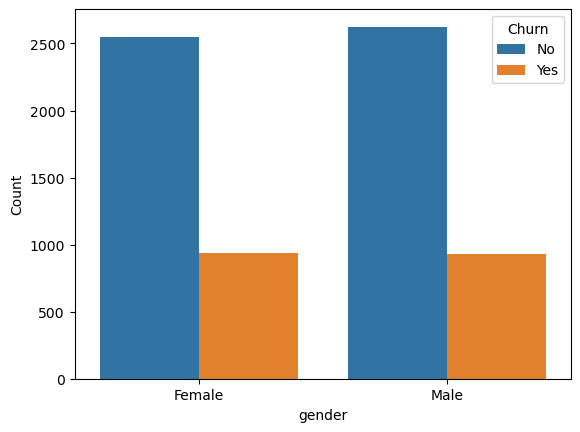

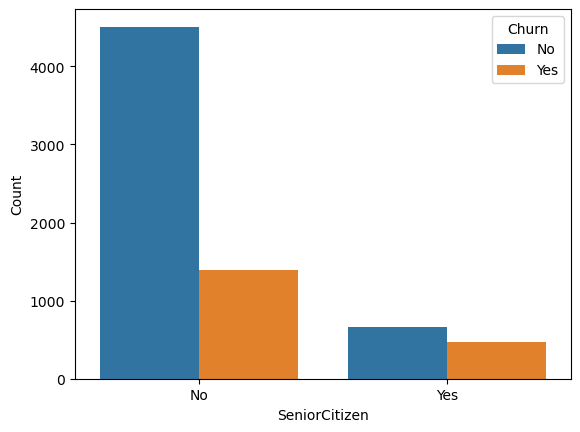

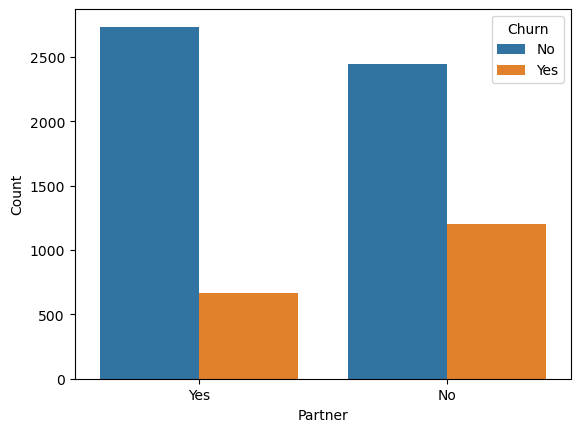

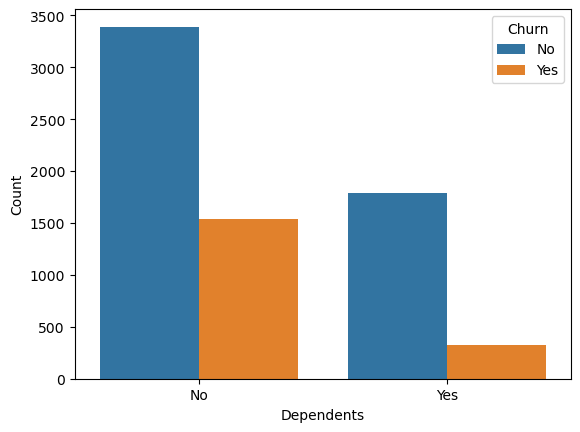

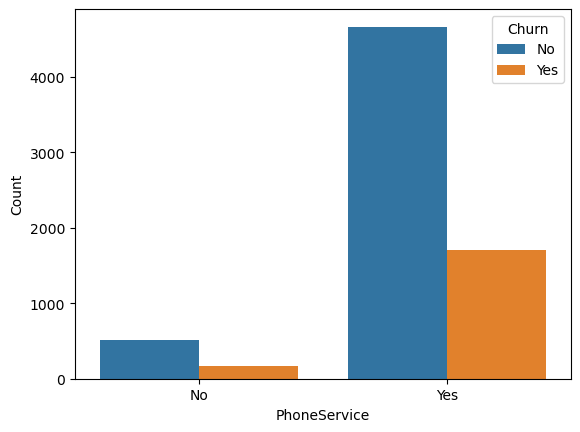

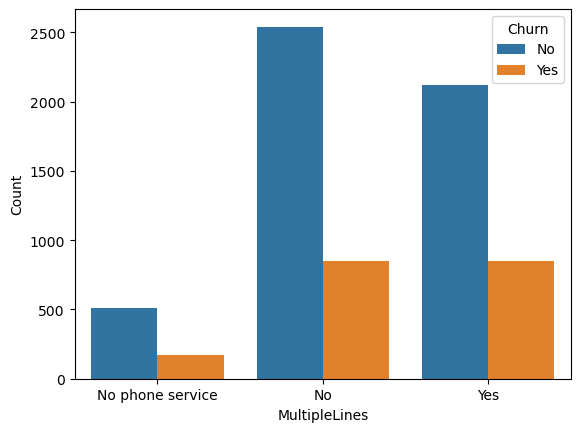

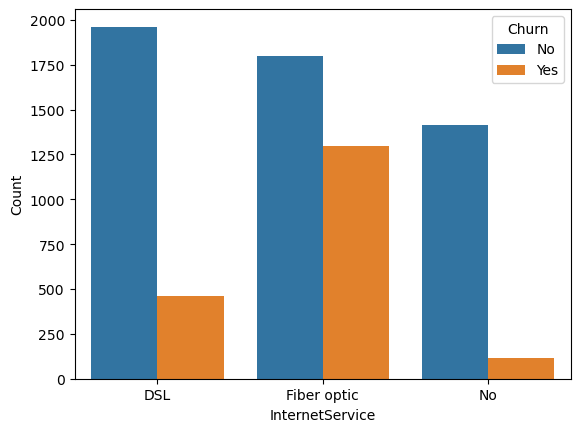

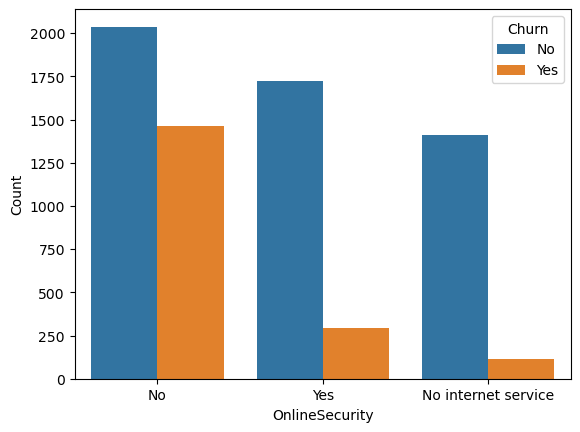

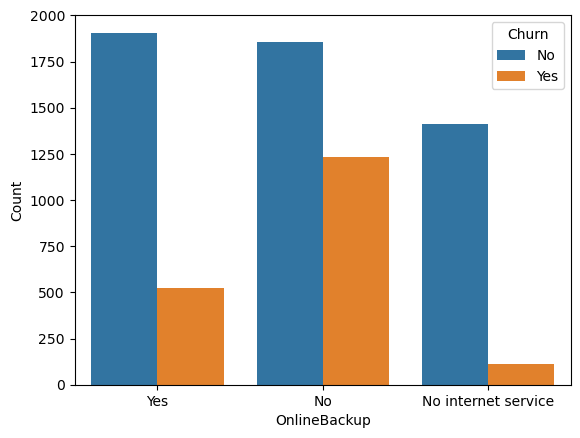

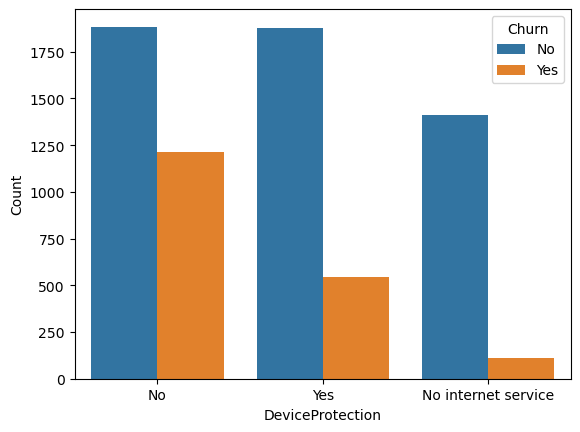

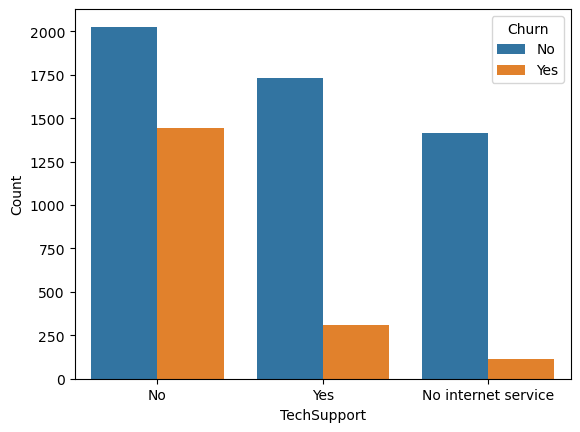

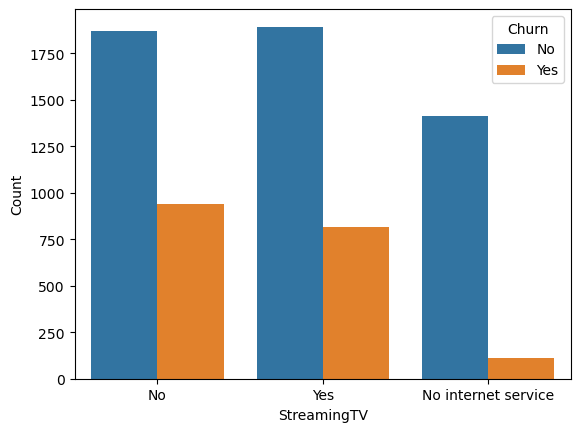

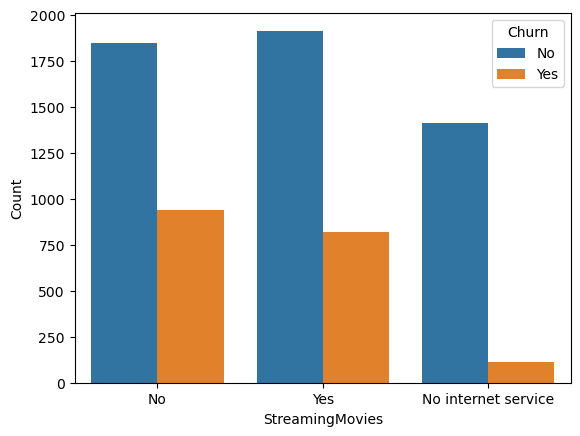

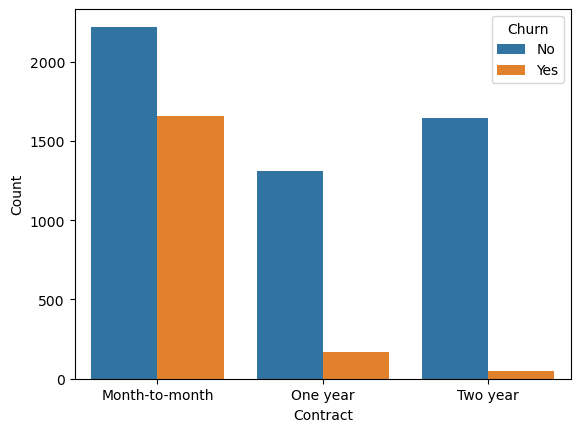

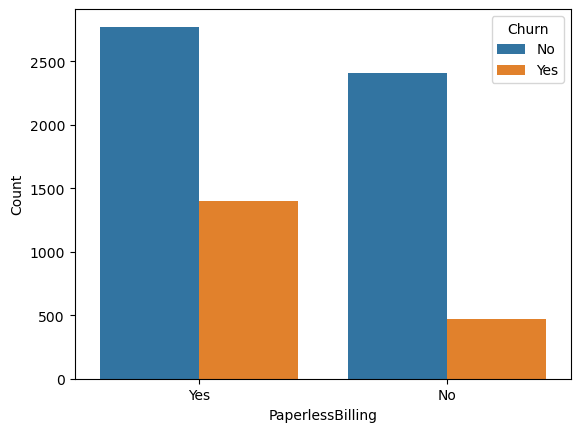

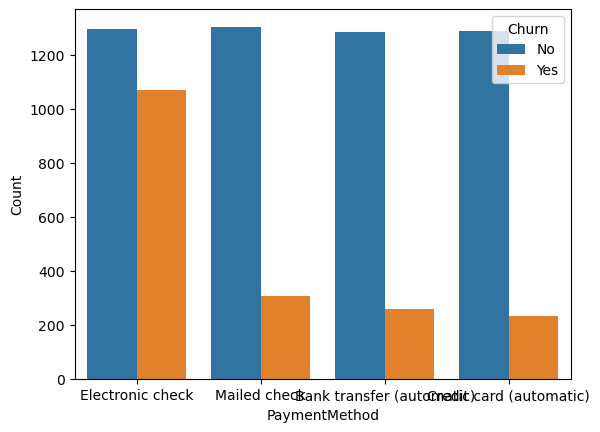

In [48]:
for col in cat_var:
    sns.countplot(data = data, x = col, hue = "Churn")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [51]:
num_var = [col for col in data.columns if data[col].dtype != "O"]

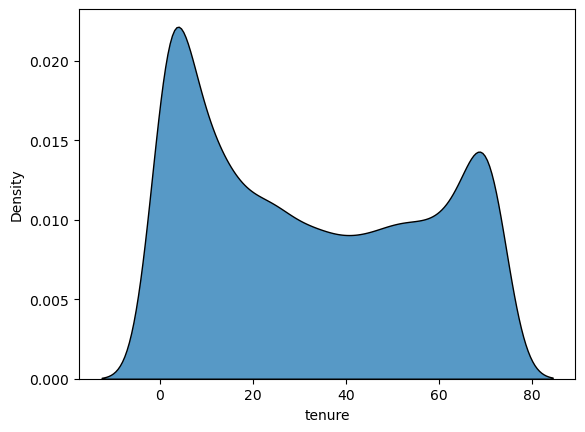

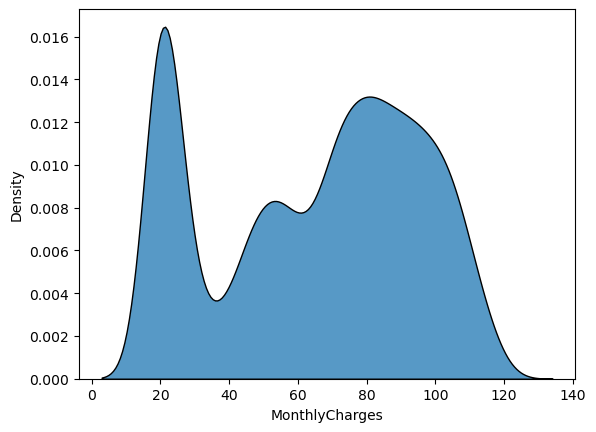

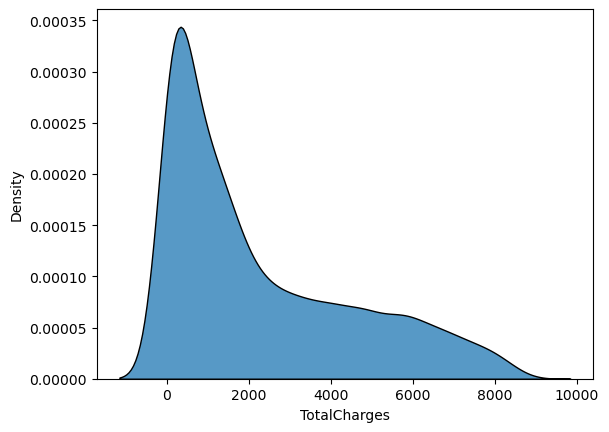

In [52]:
for feat in num_var:
    data2 = data.copy()
    sns.kdeplot(data = data2, x = feat, multiple = "stack")
    plt.xlabel(feat)
    plt.ylabel("Density")
    plt.show()

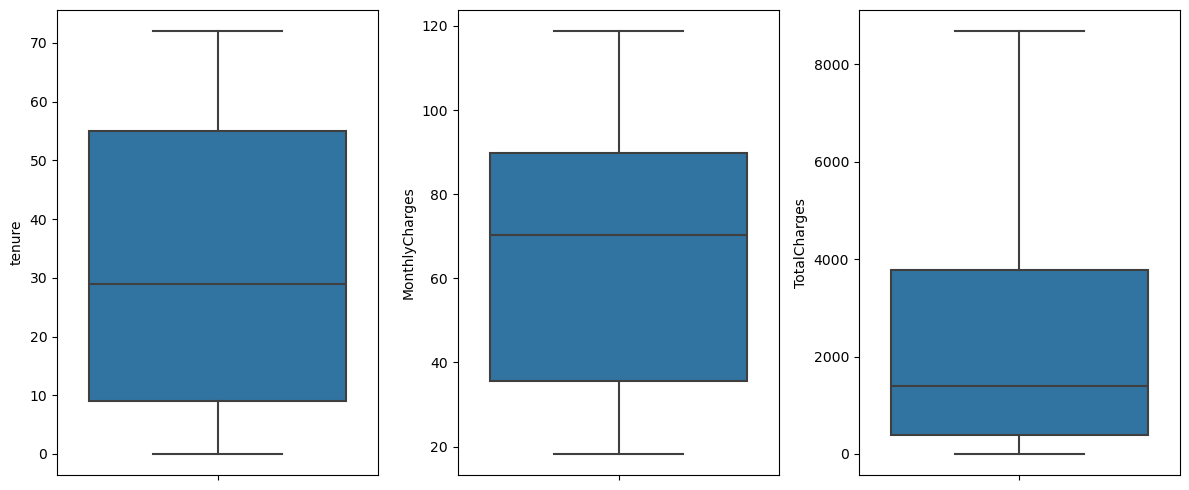

In [53]:
plt.figure(figsize = (12, 5))

for i, col in enumerate(num_var, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y = data[col])
    plt.ylabel(col)

plt.tight_layout()
plt.show()

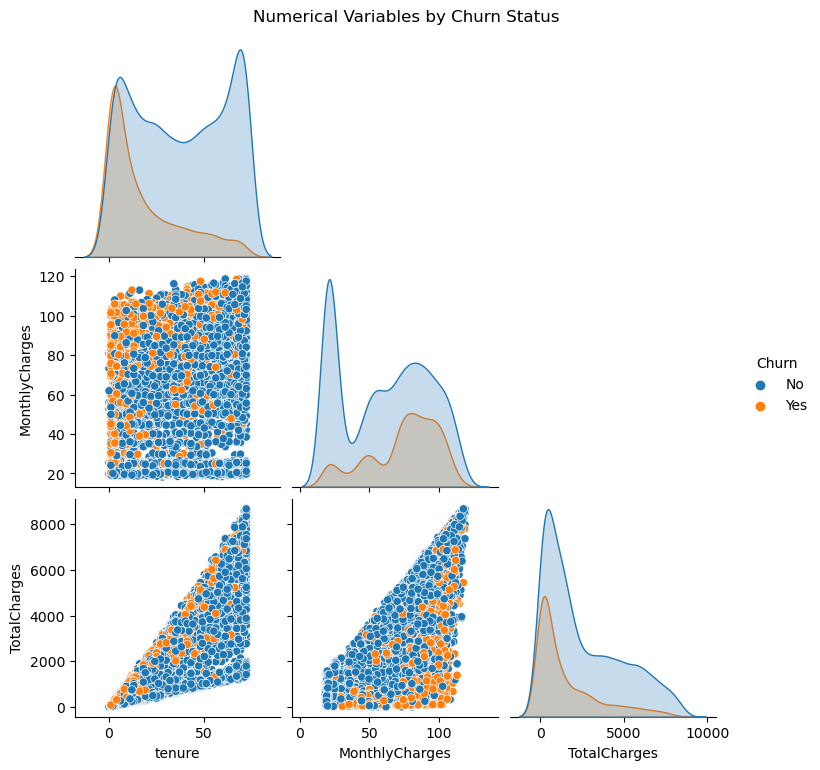

In [54]:
sns.pairplot(data, vars = num_var, hue = "Churn", diag_kind="kde", corner=True)
plt.suptitle("Numerical Variables by Churn Status", y = 1.02)
plt.show()

In [55]:
corr = data[num_var].corr()
display(corr)

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


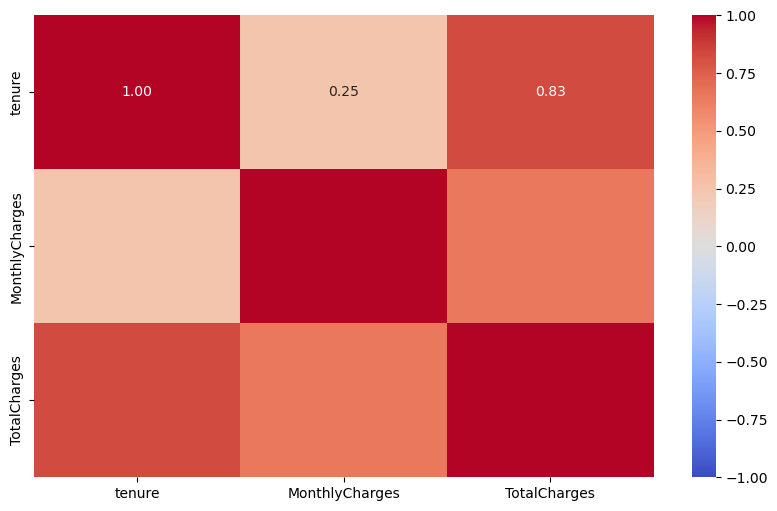

In [56]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot = True, fmt = ".2f", cmap = "coolwarm", vmin= -1, vmax = 1)
plt.show()

In [57]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vIf
X_vif = data[num_var].copy()
vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [vIf(X_vif.values, i) for i in range(X_vif.shape[1])]

In [58]:
display(vif)

,Variable,VIF
0,tenure,6.332328
1,MonthlyCharges,3.355660
2,TotalCharges,8.075070


In [59]:
X_vif = data[["tenure", "MonthlyCharges"]].copy()
vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [vIf(X_vif.values, i) for i in range(X_vif.shape[1])]

In [60]:
display(vif)

,Variable,VIF
0,tenure,2.612607
1,MonthlyCharges,2.612607


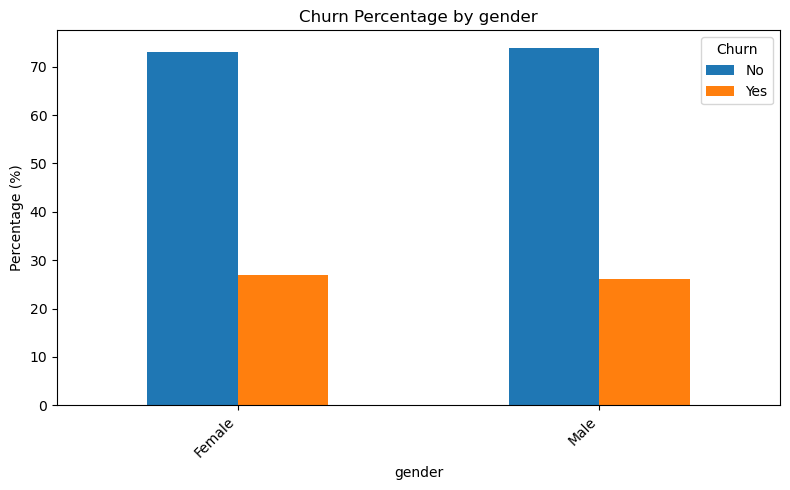

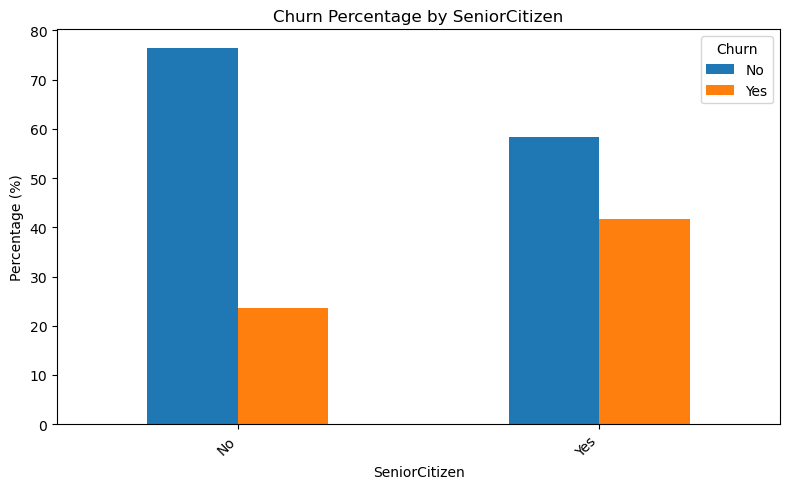

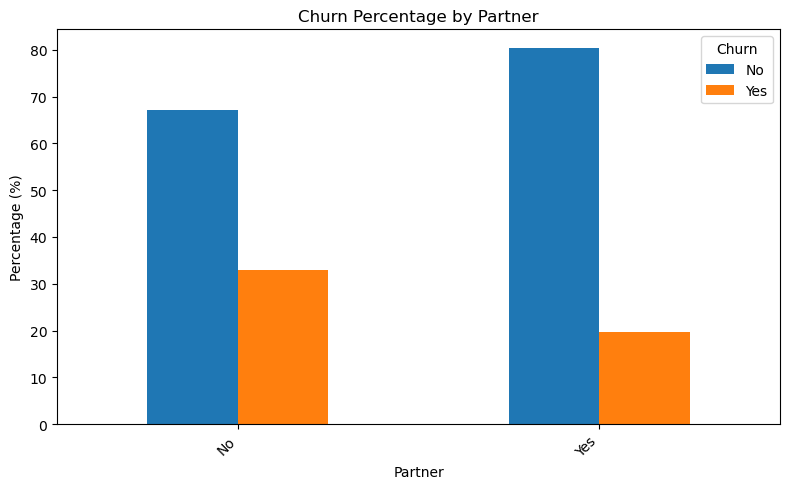

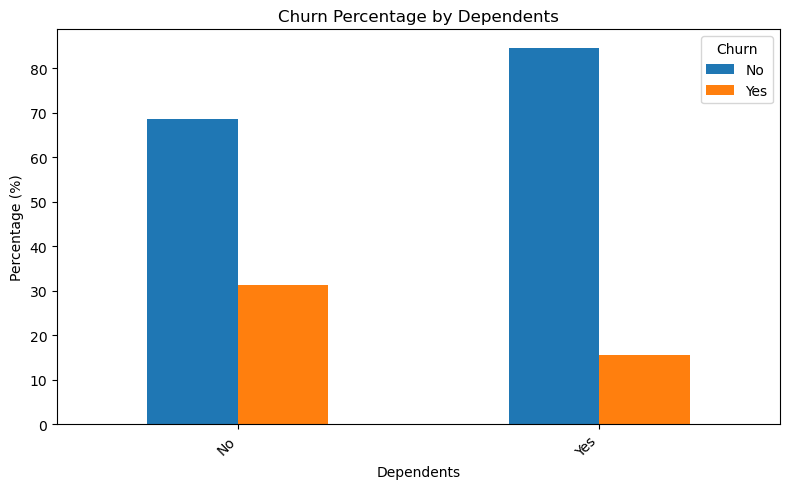

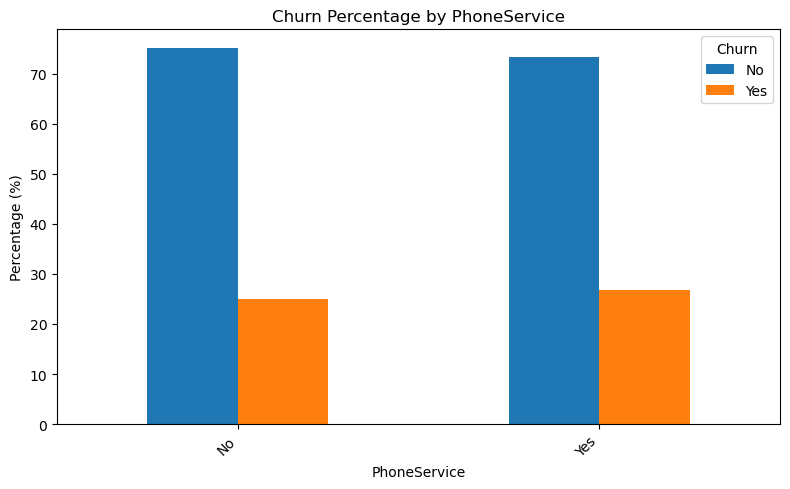

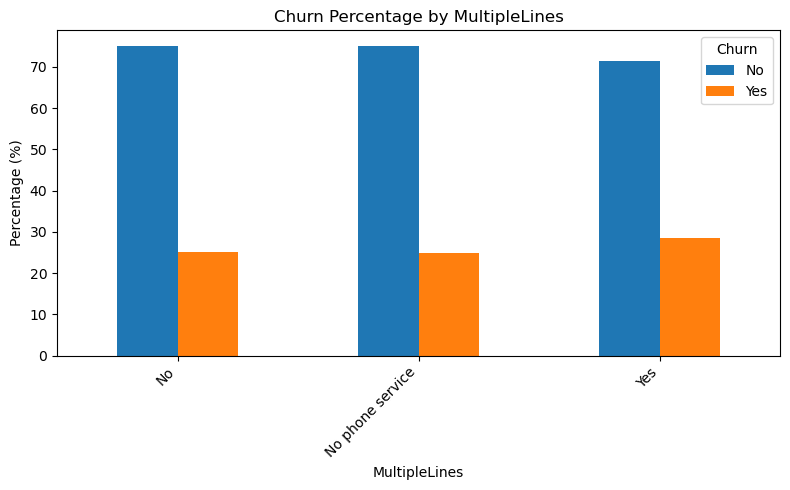

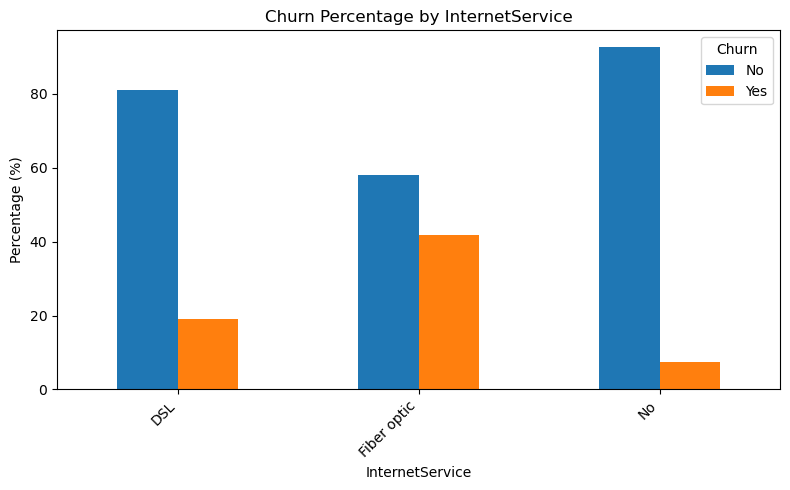

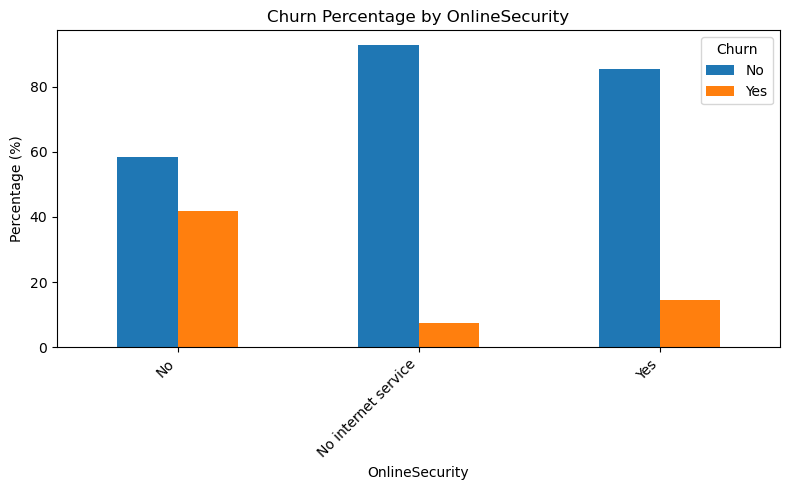

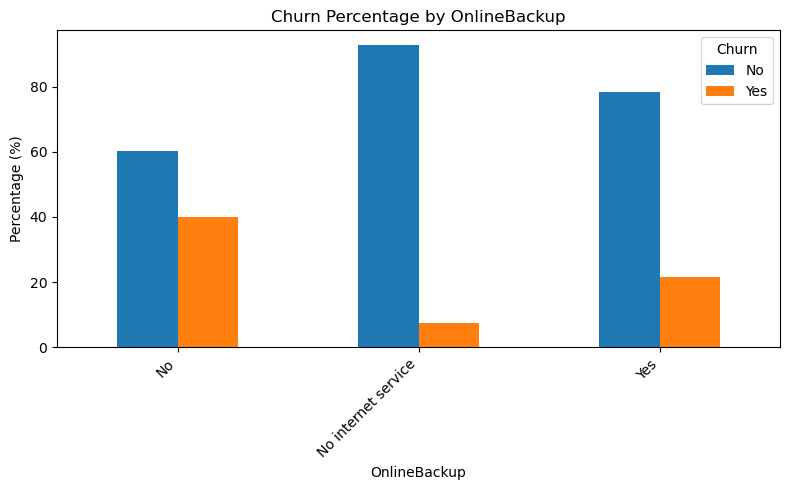

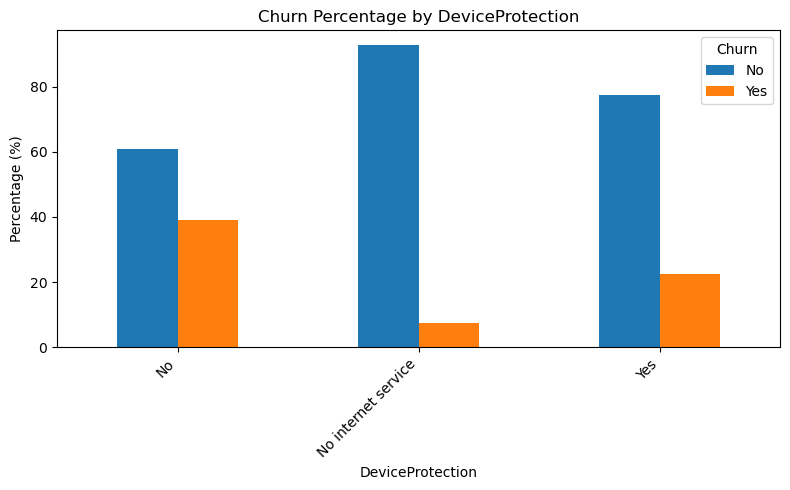

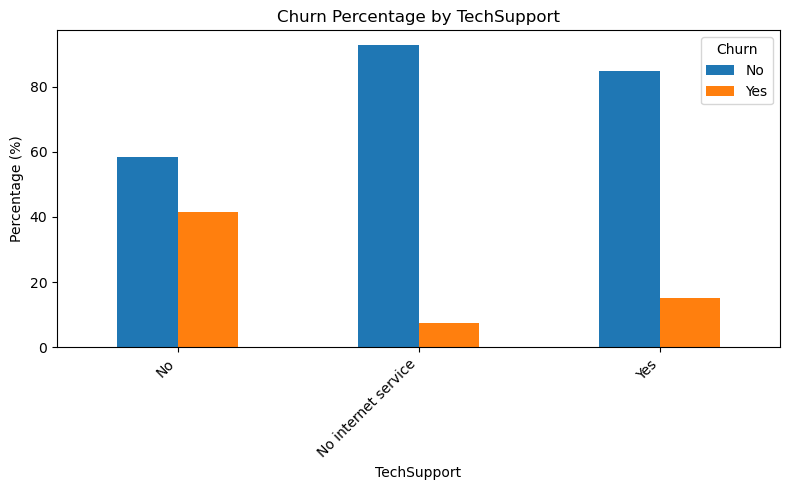

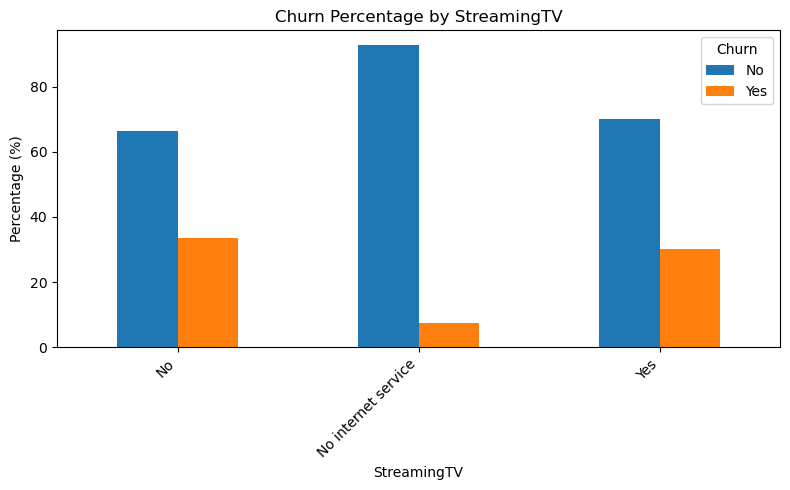

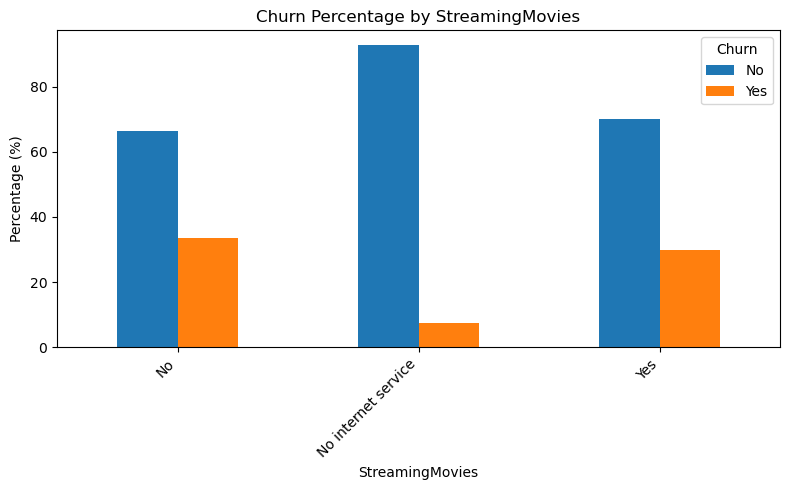

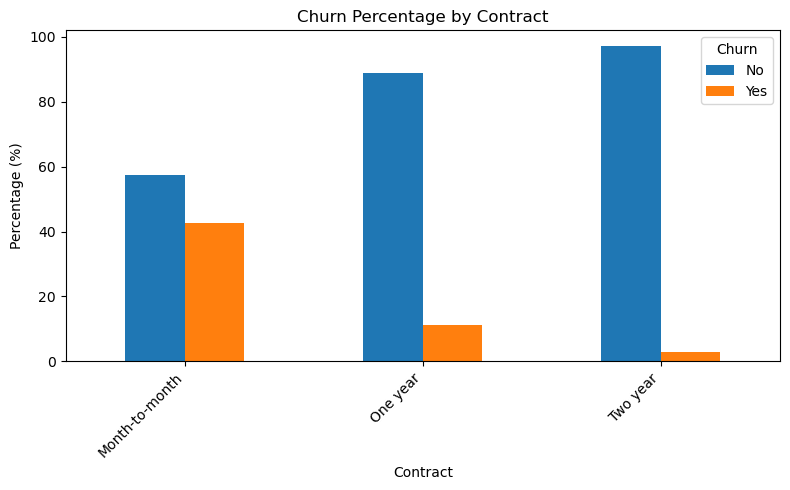

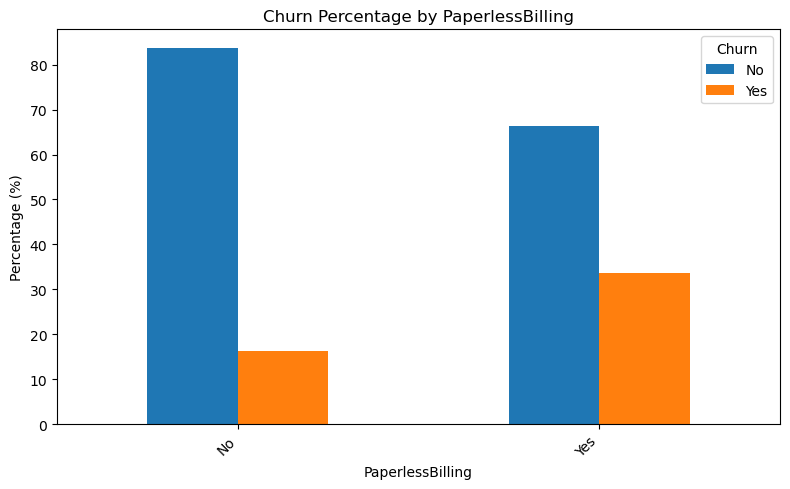

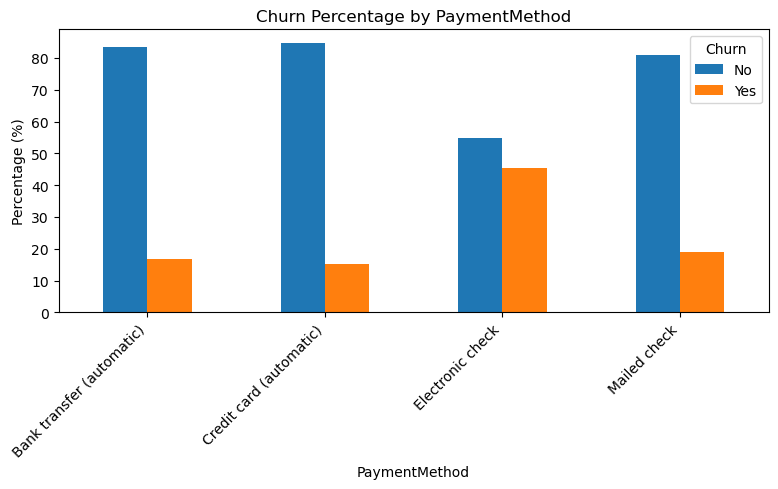

In [61]:
for col in cat_var:
    churn_pct = (pd.crosstab(data[col], data["Churn"], normalize="index")*100)
    churn_pct.plot(kind = "bar", figsize = (8, 5))
    plt.title(f"Churn Percentage by {col}")
    plt.xlabel(col)
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation = 45, ha = "right")
    plt.tight_layout()
    plt.show()

In [62]:
for col in cat_var:
    print((data[col].value_counts(normalize = True) * 100).round(2))

gender
Male      50.48
Female    49.52
Name: proportion, dtype: float64
SeniorCitizen
No     83.79
Yes    16.21
Name: proportion, dtype: float64
Partner
No     51.7
Yes    48.3
Name: proportion, dtype: float64
Dependents
No     70.04
Yes    29.96
Name: proportion, dtype: float64
PhoneService
Yes    90.32
No      9.68
Name: proportion, dtype: float64
MultipleLines
No                  48.13
Yes                 42.18
No phone service     9.68
Name: proportion, dtype: float64
InternetService
Fiber optic    43.96
DSL            34.37
No             21.67
Name: proportion, dtype: float64
OnlineSecurity
No                     49.67
Yes                    28.67
No internet service    21.67
Name: proportion, dtype: float64
OnlineBackup
No                     43.84
Yes                    34.49
No internet service    21.67
Name: proportion, dtype: float64
DeviceProtection
No                     43.94
Yes                    34.39
No internet service    21.67
Name: proportion, dtype: float64
TechSu

In [63]:
for col in cat_var:
    print((data[col].value_counts()))

gender
Male      3555
Female    3488
Name: count, dtype: int64
SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Nam

In [65]:
churn_summary = []
for col in cat_var:
    churn_rate = (pd.crosstab(data[col], data["Churn"], normalize= "index") * 100)
    for cat in churn_rate.index:
        churn_summary.append({"Variable": col, "Category": cat, "Churn Rate (%)": churn_rate.loc[cat, "Yes"]})
churn_summary = pd.DataFrame(churn_summary)
churn_summary = churn_summary.sort_values("Churn Rate (%)", ascending=False)

display(churn_summary)

,Variable,Category,Churn Rate (%)
41,PaymentMethod,Electronic check,45.285412
34,Contract,Month-to-month,42.709677
14,InternetService,Fiber optic,41.892765
16,OnlineSecurity,No,41.766724
3,SeniorCitizen,Yes,41.681261
25,TechSupport,No,41.635474
19,OnlineBackup,No,39.928756
22,DeviceProtection,No,39.127625
31,StreamingMovies,No,33.680431
38,PaperlessBilling,Yes,33.565092


In [66]:
churn_summary = []
for col in cat_var:
    hurn_rate = (pd.crosstab(data[col], data["Churn"], normalize= "index") * 100)

    display(churn_rate)
    display(churn_rate.index)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


Index(['Bank transfer (automatic)', 'Credit card (automatic)',
       'Electronic check', 'Mailed check'],
      dtype='object', name='PaymentMethod')

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


Index(['Bank transfer (automatic)', 'Credit card (automatic)',
       'Electronic check', 'Mailed check'],
      dtype='object', name='PaymentMethod')

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


...

Index(['Bank transfer (automatic)', 'Credit card (automatic)',
       'Electronic check', 'Mailed check'],
      dtype='object', name='PaymentMethod')

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


Index(['Bank transfer (automatic)', 'Credit card (automatic)',
       'Electronic check', 'Mailed check'],
      dtype='object', name='PaymentMethod')

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


Index(['Bank transfer (automatic)', 'Credit card (automatic)',
       'Electronic check', 'Mailed check'],
      dtype='object', name='PaymentMethod')

In [67]:
churn_rate.index

Index(['Bank transfer (automatic)', 'Credit card (automatic)',
       'Electronic check', 'Mailed check'],
      dtype='object', name='PaymentMethod')

In [68]:
from sklearn.preprocessing import StandardScaler

In [69]:
X = data.drop("Churn", axis = 1)
y = data["Churn"].map({"No": 0, "Yes": 1})
X_encoded = pd.get_dummies(X, drop_first=True, dtype=int)

In [70]:
X_encoded

,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0
1,34,56.95,1889.50,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1
2,2,53.85,108.15,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
3,45,42.30,1840.75,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0
4,2,70.70,151.65,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,24,84.80,1990.50,1,0,1,1,1,0,1,0,0,0,1,0,0,0,1,0,1,0,1,0,1,1,0,1,0,0,1
7039,72,103.20,7362.90,0,0,1,1,1,0,1,1,0,0,0,0,1,0,1,0,0,0,1,0,1,1,0,1,1,0,0
7040,11,29.60,346.45,0,0,1,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0
7041,4,74.40,306.60,1,1,1,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1


In [71]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [72]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_encoded, y, stratify=y, test_size=0.2, random_state=42)


In [73]:
X_train.head()

,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,35,49.20,1701.65,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0
3151,15,75.10,1151.55,1,0,1,1,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4860,13,40.55,590.35,1,0,1,1,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1
3867,26,73.50,1905.70,0,0,1,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,1,1,0,0
3810,1,44.55,44.55,1,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [74]:
X_val.head()

,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
437,72,114.05,8468.20,1,0,1,1,1,0,1,1,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,1,1,0,0
2280,8,100.15,908.55,0,1,0,0,1,0,1,1,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,1,1,0,0
2235,41,78.35,3211.20,0,0,1,1,1,0,1,0,0,0,1,0,1,0,1,0,0,0,1,0,0,1,0,1,1,0,0
4460,18,78.20,1468.75,1,0,1,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0
3761,72,82.65,5919.35,0,0,1,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,0,0


In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [77]:
dtc = DecisionTreeClassifier(random_state=42)
dt_param_grid = {
    "criterion": ['gini', 'entropy', 'log_loss'],
    "max_depth": [2, 5, 9, 10, None],
    "min_samples_split": [2, 5, 10, 15, 20],
    "min_samples_leaf": [2, 5, 10],
    "max_features": [None, "sqrt", "log2"]
}
dt_grid = GridSearchCV(
    estimator = dtc,
    param_grid = dt_param_grid,
    cv = 5,
    scoring="roc_auc",
    n_jobs = -1,
    verbose = 1
)

dt_grid.fit(X_train, y_train)

print("Best DTC parameters: ")
print(dt_grid.best_params_)

print("\nBest cross-validation ROC-AUC: ")
print(dt_grid.best_score_)
    

Fitting 5 folds for each of 675 candidates, totalling 3375 fits
Best DTC parameters: 
{'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}

Best cross-validation ROC-AUC: 
0.825658617044968


In [78]:
rfc = RandomForestClassifier(random_state=42)
rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "criterion": ['gini', 'entropy'],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [2, 5, 10],
    "max_features": [None, "sqrt", "log2"]
}

In [79]:
rf_grid = GridSearchCV(
    estimator = rfc,
    param_grid = rf_param_grid,
    cv = 5,
    scoring="roc_auc",
    n_jobs = -1,
    verbose = 1
)

rf_grid.fit(X_train, y_train)

print("Best RFC parameters: ")
print(rf_grid.best_params_)

print("\nBest cross-validation ROC-AUC: ")
print(rf_grid.best_score_)

Fitting 5 folds for each of 486 candidates, totalling 2430 fits
Best RFC parameters: 
{'criterion': 'entropy', 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 10, 'min_samples_split': 2, 'n_estimators': 200}

Best cross-validation ROC-AUC: 
0.8472458099519609


In [80]:
best_rfc = rf_grid.best_estimator_

print("Best RFC Parameters:")
print(rf_grid.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(rf_grid.best_score_, 6))


Best RFC Parameters:
{'criterion': 'entropy', 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 10, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validation ROC-AUC:
0.847246


In [81]:
dtc.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [82]:
y_pred = best_rfc.predict(X_val)

# Probability of Churn = Yes
y_prob = best_rfc.predict_proba(X_val)[:, 1]

In [83]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

In [84]:
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_prob)

In [85]:
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Accuracy:  0.8006
Precision: 0.6691
Recall:    0.4920
F1-Score:  0.5670
ROC-AUC:   0.8430


In [86]:
print("\nClassification Report:")
print(classification_report(
    y_val,
    y_pred,
    target_names=["No Churn", "Churn"]
))


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1035
       Churn       0.67      0.49      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [87]:
cm = confusion_matrix(y_val, y_pred)

print("\nConfusion Matrix:")
print(cm)



Confusion Matrix:
[[944  91]
 [190 184]]


ROC-AUC: 0.8430


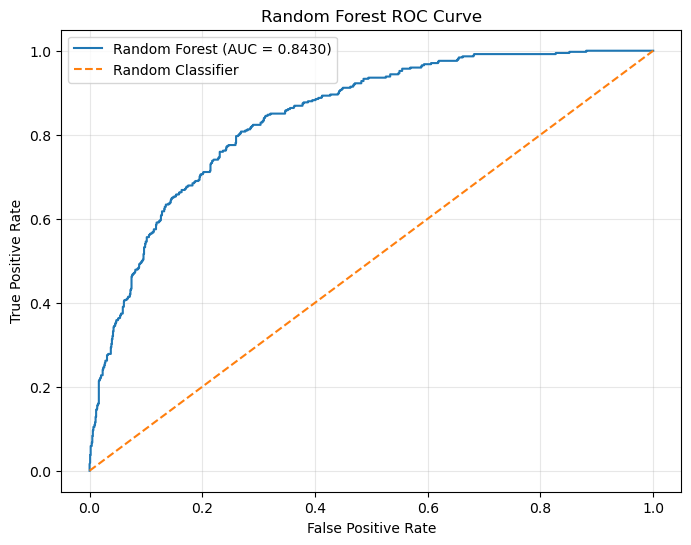

In [88]:
from sklearn.metrics import roc_curve
# ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_prob)

roc_auc = roc_auc_score(y_val, y_prob)

print(f"ROC-AUC: {roc_auc:.4f}")


# ------------------------------------------------
# 2. Plot ROC curve
# ------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [89]:
# ------------------------------------------------
# 3. Find the threshold using Youden's J statistic
# ------------------------------------------------

youden_j = tpr - fpr

best_index = np.argmax(youden_j)

best_threshold = thresholds[best_index]

print(f"Best threshold (Youden's J): {best_threshold:.4f}")


Best threshold (Youden's J): 0.2812


In [90]:


# ------------------------------------------------
# 4. Make predictions using the new threshold
# ------------------------------------------------

y_pred_threshold = (
    y_prob >= best_threshold
).astype(int)


threshold_accuracy = accuracy_score(
    y_val,
    y_pred_threshold
)

threshold_precision = precision_score(
    y_val,
    y_pred_threshold
)

threshold_recall = recall_score(
    y_val,
    y_pred_threshold
)

threshold_f1 = f1_score(
    y_val,
    y_pred_threshold
)


print("\n==========================================")
print("THRESHOLD-OPTIMIZED RANDOM FOREST")
print("==========================================")

print(f"Threshold:  {best_threshold:.4f}")
print(f"Accuracy:   {threshold_accuracy:.4f}")
print(f"Precision:  {threshold_precision:.4f}")
print(f"Recall:     {threshold_recall:.4f}")
print(f"F1-Score:   {threshold_f1:.4f}")


THRESHOLD-OPTIMIZED RANDOM FOREST
Threshold:  0.2812
Accuracy:   0.7516
Precision:  0.5207
Recall:     0.8075
F1-Score:   0.6331


In [91]:
# Best Decision Tree from GridSearchCV
best_dtc = dt_grid.best_estimator_

# Predictions
dt_pred = best_dtc.predict(X_val)
dt_prob = best_dtc.predict_proba(X_val)[:, 1]

In [92]:
dt_accuracy = accuracy_score(y_val, dt_pred)
dt_precision = precision_score(y_val, dt_pred)
dt_recall = recall_score(y_val, dt_pred)
dt_f1 = f1_score(y_val, dt_pred)
dt_roc_auc = roc_auc_score(y_val, dt_prob)

print("==========================================")
print("OPTIMIZED DECISION TREE PERFORMANCE")
print("==========================================")

print(f"Accuracy:  {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall:    {dt_recall:.4f}")
print(f"F1-Score:  {dt_f1:.4f}")
print(f"ROC-AUC:   {dt_roc_auc:.4f}")

OPTIMIZED DECISION TREE PERFORMANCE
Accuracy:  0.7935
Precision: 0.6531
Recall:    0.4733
F1-Score:  0.5488
ROC-AUC:   0.8301


In [93]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, dt_pred))

print("\nClassification Report:")
print(classification_report(
    y_val,
    dt_pred,
    target_names=["No Churn", "Churn"]
))


Confusion Matrix:
[[941  94]
 [197 177]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1035
       Churn       0.65      0.47      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [94]:
comparison = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Random Forest (0.50)',
        'Random Forest (0.2812)'
    ],
    'Accuracy': [
        dt_accuracy,
        0.8006,
        0.7516
    ],
    'Precision': [
        dt_precision,
        0.6691,
        0.5207
    ],
    'Recall': [
        dt_recall,
        0.4920,
        0.8075
    ],
    'F1-Score': [
        dt_f1,
        0.5670,
        0.6331
    ],
    'ROC-AUC': [
        dt_roc_auc,
        0.8430,
        0.8430
    ]
})

display(comparison.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,0.7935,0.6531,0.4733,0.5488,0.8301
1,Random Forest (0.50),0.8006,0.6691,0.4920,0.5670,0.8430
2,Random Forest (0.2812),0.7516,0.5207,0.8075,0.6331,0.8430


In [95]:
# ==========================================
# FINAL MODEL COMPARISON
# ==========================================

comparison = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Random Forest (Threshold = 0.50)',
        'Random Forest (Threshold = 0.2812)'
    ],
    'Accuracy': [
        dt_accuracy,
        0.8006,
        0.7516
    ],
    'Precision': [
        dt_precision,
        0.6691,
        0.5207
    ],
    'Recall': [
        dt_recall,
        0.4920,
        0.8075
    ],
    'F1-Score': [
        dt_f1,
        0.5670,
        0.6331
    ],
    'ROC-AUC': [
        dt_roc_auc,
        0.8430,
        0.8430
    ]
})

print("==========================================")
print("FINAL MODEL COMPARISON")
print("==========================================")

display(comparison.round(4))

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,0.7935,0.6531,0.4733,0.5488,0.8301
1,Random Forest (Threshold = 0.50),0.8006,0.6691,0.4920,0.5670,0.8430
2,Random Forest (Threshold = 0.2812),0.7516,0.5207,0.8075,0.6331,0.8430


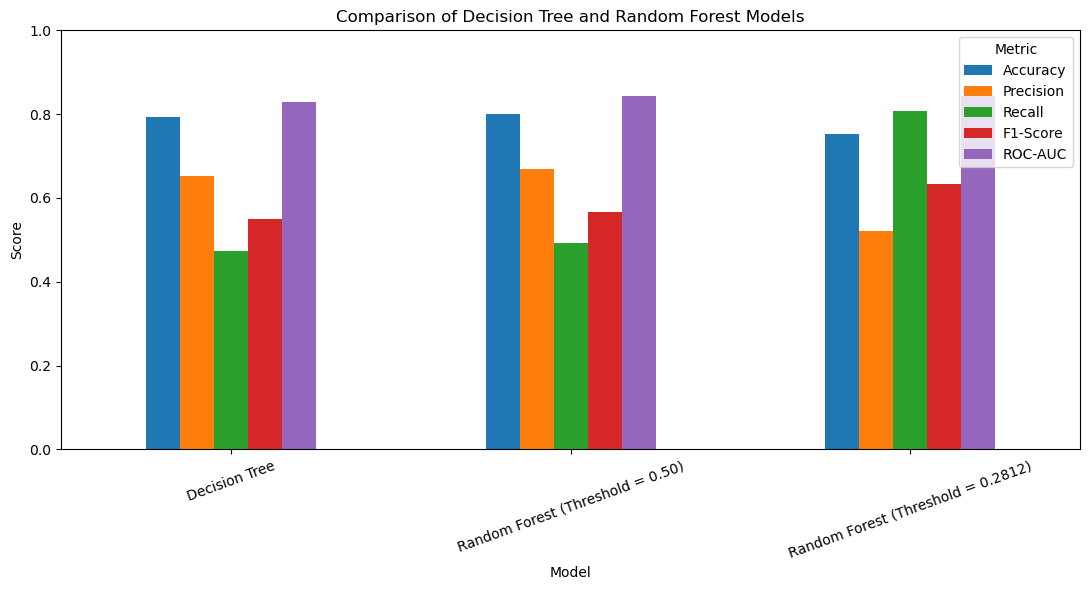

In [96]:
# ==========================================
# MODEL PERFORMANCE COMPARISON
# ==========================================

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

comparison.set_index('Model')[metrics].plot(
    kind='bar',
    figsize=(11, 6)
)

plt.title('Comparison of Decision Tree and Random Forest Models')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

FINAL RANDOM FOREST CONFUSION MATRIX
[[757 278]
 [ 73 301]]

TN: 757
FP: 278
FN: 73
TP: 301


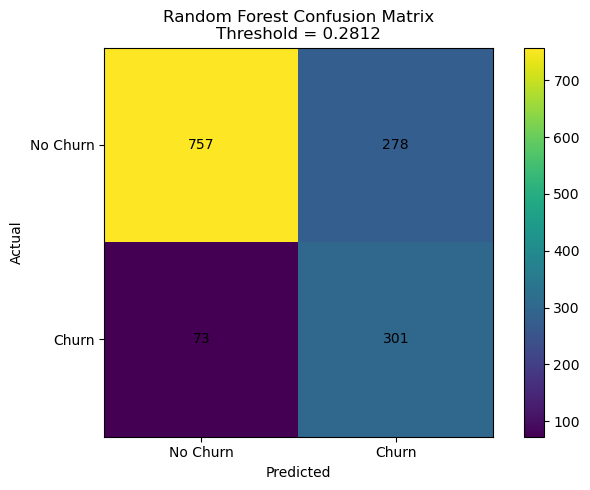

In [97]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Final predictions using Youden's J threshold
final_threshold = 0.2812

y_final_pred = (y_prob >= final_threshold).astype(int)

# Confusion matrix
cm_final = confusion_matrix(y_val, y_final_pred)

print("==========================================")
print("FINAL RANDOM FOREST CONFUSION MATRIX")
print("==========================================")
print(cm_final)

print("\nTN:", cm_final[0, 0])
print("FP:", cm_final[0, 1])
print("FN:", cm_final[1, 0])
print("TP:", cm_final[1, 1])

# Plot
plt.figure(figsize=(7, 5))

plt.imshow(cm_final)

plt.title("Random Forest Confusion Matrix\nThreshold = 0.2812")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

for i in range(2):
    for j in range(2):
        plt.text(
            j, i,
            cm_final[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [98]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore'
            ),
            cat_var
        ),
        (
            'numerical',
            'passthrough',
            num_var
        )
    ]
)

In [99]:
best_params = rf_grid.best_params_

print("Best RFC parameters:")
print(best_params)

final_rfc = RandomForestClassifier(
    **best_params,
    random_state=42
)

final_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', final_rfc)
    ]
)

Best RFC parameters:
{'criterion': 'entropy', 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 10, 'min_samples_split': 2, 'n_estimators': 200}


In [100]:
import joblib
final_pipeline.fit(X, y)

joblib.dump(
    final_pipeline,
    'churn_model.joblib'
)


print("\n==========================================")
print("DEPLOYMENT MODEL CREATED")
print("==========================================")

print("Model saved as: churn_model.joblib")


DEPLOYMENT MODEL CREATED
Model saved as: churn_model.joblib


In [101]:
customer = pd.DataFrame([{
    'gender': 'Female',
    'SeniorCitizen': 'No',
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 12,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 85.50,
    'TotalCharges': 1026.00
}])


In [102]:
model = joblib.load("churn_model.joblib")

churn_probability = model.predict_proba(customer)[0, 1]

# Your optimized threshold
threshold = 0.2812

if churn_probability >= threshold:
    prediction = "Churn"
else:
    prediction = "No Churn"



print(f"Churn Probability: {churn_probability:.2%}")
print(f"Classification Threshold: {threshold}")
print(f"Prediction: {prediction}")

Churn Probability: 63.22%
Classification Threshold: 0.2812
Prediction: Churn


In [103]:

# Save the optimized Random Forest model
joblib.dump(rfc, "rfc_churn_model.pkl")

# Save the optimized classification threshold
joblib.dump(0.2812, "churn_threshold.pkl")

print("Random Forest model saved successfully.")
print("Threshold saved successfully.")

Random Forest model saved successfully.
Threshold saved successfully.
